In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/Universities.csv')

In [5]:
df

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90
5,Dartmouth,1340,89,23,10,32162,95
6,Duke,1315,90,30,12,31585,95
7,Georgetown,1255,74,24,12,20126,92
8,Harvard,1400,91,14,11,39525,97
9,JohnsHopkins,1305,75,44,7,58691,87


In [7]:
# Normalization function  this is the predf function for norming the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_unvi_df = scaler.fit_transform(df.iloc[:,1:])

In [8]:
# How to find the optimum number of cluster
# The K-menas algorithm aims to choose centroid that menimise the inertia 
# or within-cluster sum-of-sauare

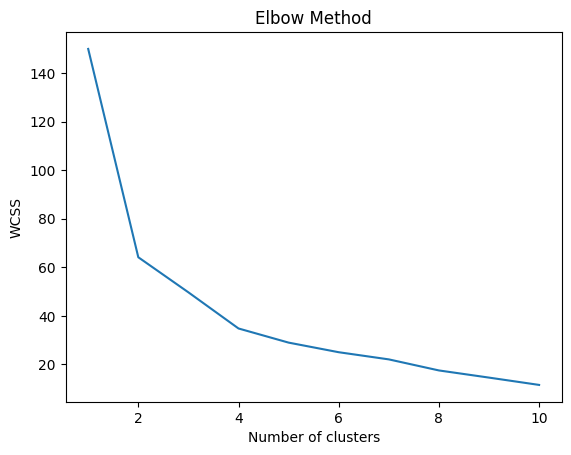

In [15]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters =i ,random_state=0) #making the cluster
    kmeans.fit(scaled_unvi_df) #fitting the model
    wcss.append(kmeans.inertia_)  # avg of the avgs of distances of datapoint to Centroides

plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
    

In [18]:
# Build Culster Algorithm
from sklearn.cluster import KMeans
cluster_new = KMeans(4,random_state =42)    #random state is 42 so that the partiton will be same and will not be changed
cluster_new.fit(scaled_unvi_df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [21]:
cluster_new.labels_

array([2, 0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 3, 2, 2, 1, 2,
       2, 1, 2], dtype=int32)

In [36]:
# Assign cluster to the dataset
df['clusterid_new'] = cluster_new.labels_

In [37]:
df


,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster_new,clusterid_new
0,Brown,1310,89,22,13,22704,94,2,2
1,CalTech,1415,100,25,6,63575,81,0,0
2,CMU,1260,62,59,9,25026,72,1,1
3,Columbia,1310,76,24,12,31510,88,2,2
4,Cornell,1280,83,33,13,21864,90,2,2
5,Dartmouth,1340,89,23,10,32162,95,2,2
6,Duke,1315,90,30,12,31585,95,2,2
7,Georgetown,1255,74,24,12,20126,92,2,2
8,Harvard,1400,91,14,11,39525,97,2,2
9,JohnsHopkins,1305,75,44,7,58691,87,0,0


In [38]:
# these are standardised values
cluster_new.cluster_centers_

array([[ 0.88122441,  0.5787432 , -0.24316128, -1.56078563,  2.38759968,
        -0.3064867 ],
       [-1.35856999, -1.56922385,  1.49000956,  0.67249284, -0.92455897,
        -1.27552555],
       [ 0.4019729 ,  0.47834204, -0.4942352 , -0.19543032,  0.06879803,
         0.5419194 ],
       [-1.8031381 , -1.44318177,  1.43827311,  3.08142243, -1.32197103,
        -2.22202861]])

In [39]:
df.groupby('cluster_new').agg('mean',numeric_only = True).reset_index()

,cluster_new,SAT,Top10,Accept,SFRatio,Expenses,GradRate,clusterid_new
0,0,1360.000000,87.500000,34.500000,6.500000,61133.000000,84.000000,0.0
1,1,1122.200000,46.600000,68.000000,15.400000,14320.800000,75.400000,1.0
2,2,1309.117647,85.588235,29.647059,11.941176,28360.352941,91.529412,2.0
3,3,1075.000000,49.000000,67.000000,25.000000,8704.000000,67.000000,3.0


In [40]:
df

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster_new,clusterid_new
0,Brown,1310,89,22,13,22704,94,2,2
1,CalTech,1415,100,25,6,63575,81,0,0
2,CMU,1260,62,59,9,25026,72,1,1
3,Columbia,1310,76,24,12,31510,88,2,2
4,Cornell,1280,83,33,13,21864,90,2,2
5,Dartmouth,1340,89,23,10,32162,95,2,2
6,Duke,1315,90,30,12,31585,95,2,2
7,Georgetown,1255,74,24,12,20126,92,2,2
8,Harvard,1400,91,14,11,39525,97,2,2
9,JohnsHopkins,1305,75,44,7,58691,87,0,0
